# Prédiction de Carrière pour Étudiants en Informatique
**Barbara KENGNE — Licence 3 Informatique, Aix-Marseille Université**

En tant qu'étudiante en informatique moi-même, ce dataset m'a immédiatement intéressée. L'objectif : à partir du profil d'un étudiant (GPA, compétences, domaine d'intérêt...), peut-on prédire son orientation professionnelle future ?

C'est un problème de **classification multi-classe** sur données tabulaires — différent de mes projets NLP.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
print('Bibliotheques importees')

Bibliotheques importees


In [2]:
df = pd.read_csv('cs_students.csv')
print(f'Dataset : {df.shape[0]} etudiants, {df.shape[1]} colonnes')
df.head()

Dataset : 180 etudiants, 12 colonnes


,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


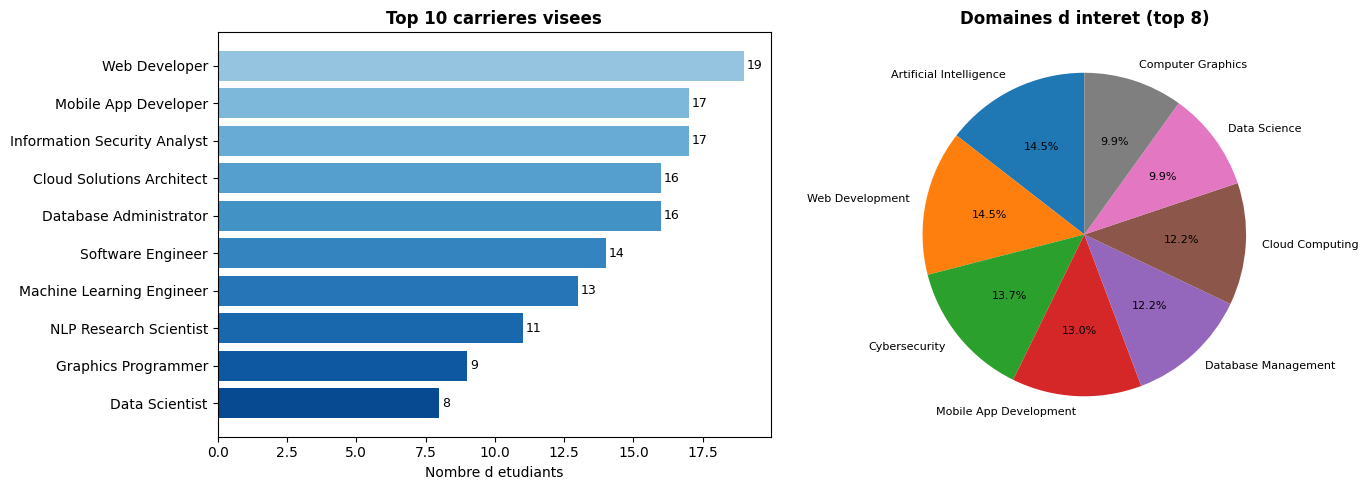

In [3]:
# Distribution des carrieres et domaines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_careers = df['Future Career'].value_counts().head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_careers)))
bars = axes[0].barh(top_careers.index[::-1], top_careers.values[::-1], color=colors[::-1])
axes[0].set_title('Top 10 carrieres visees', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Nombre d etudiants')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.1, bar.get_y() + bar.get_height()/2, str(int(w)), va='center', fontsize=9)

top_domains = df['Interested Domain'].value_counts().head(8)
axes[1].pie(top_domains, labels=top_domains.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Domaines d interet (top 8)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('distribution_carrieres.png', dpi=150, bbox_inches='tight')
plt.show()

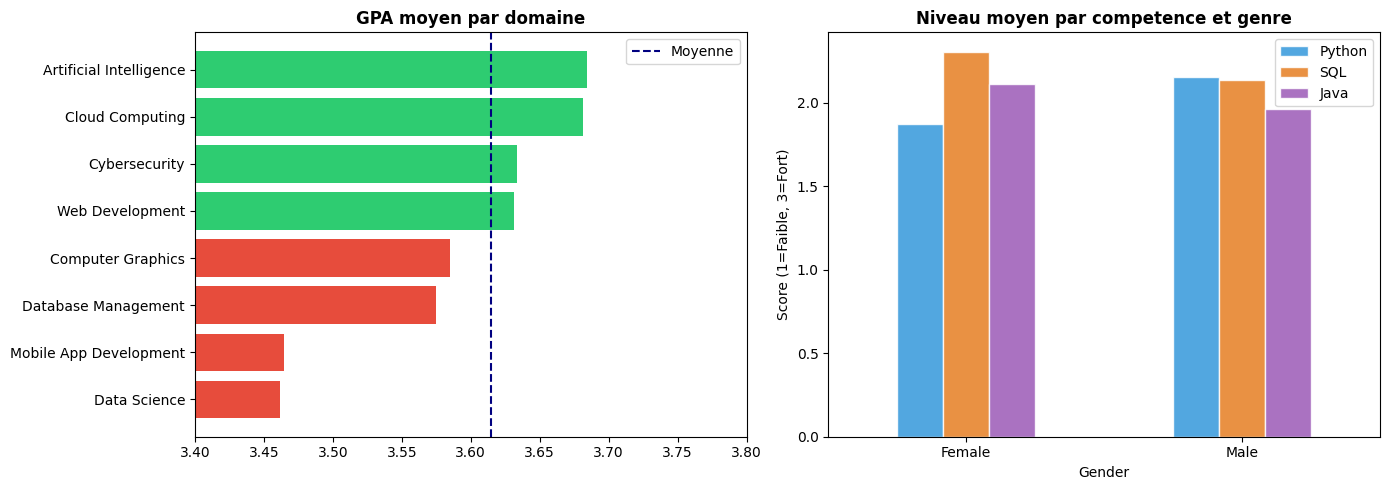

In [4]:
# GPA par domaine et competences par genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top8 = df['Interested Domain'].value_counts().head(8).index
df_top8 = df[df['Interested Domain'].isin(top8)]
gpa_domain = df_top8.groupby('Interested Domain')['GPA'].mean().sort_values()
colors_gpa = ['#e74c3c' if g < df['GPA'].mean() else '#2ecc71' for g in gpa_domain.values]
axes[0].barh(gpa_domain.index, gpa_domain.values, color=colors_gpa)
axes[0].set_xlim(3.4, 3.8)
axes[0].axvline(df['GPA'].mean(), color='navy', linestyle='--', linewidth=1.5, label='Moyenne')
axes[0].set_title('GPA moyen par domaine', fontweight='bold')
axes[0].legend()

skill_map = {'Strong': 3, 'Average': 2, 'Weak': 1}
for skill in ['Python', 'SQL', 'Java']:
    df[skill + '_num'] = df[skill].map(skill_map)
skills_by_gender = df.groupby('Gender')[['Python_num', 'SQL_num', 'Java_num']].mean()
skills_by_gender.columns = ['Python', 'SQL', 'Java']
skills_by_gender.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white', alpha=0.85)
axes[1].set_title('Niveau moyen par competence et genre', fontweight='bold')
axes[1].set_ylabel('Score (1=Faible, 3=Fort)')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('analyse_gpa_competences.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Regrouper les 33 carrieres en 6 familles
def regrouper_carriere(c):
    ia_ml = ['Machine Learning Engineer', 'Data Scientist', 'Data Analyst',
              'AI Researcher', 'NLP Research Scientist', 'NLP Engineer',
              'Computer Vision Engineer', 'Machine Learning Researcher']
    secu = ['Information Security Analyst', 'Security Analyst',
             'Ethical Hacker', 'Digital Forensics Specialist', 'Data Privacy Specialist']
    dev_web = ['Web Developer', 'UX Designer', 'SEO Specialist']
    dev_mobile = ['Mobile App Developer', 'Game Developer', 'VR Developer']
    data_cloud = ['Database Administrator', 'Cloud Solutions Architect',
                  'DevOps Engineer', 'IoT Developer']
    if c in ia_ml:      return 'IA / ML / Data Science'
    if c in secu:       return 'Cybersecurite'
    if c in dev_web:    return 'Developpement Web'
    if c in dev_mobile: return 'Dev Mobile / Jeu'
    if c in data_cloud: return 'Data / Cloud / DevOps'
    return 'Autre Ingenierie'

df['Carriere_groupe'] = df['Future Career'].apply(regrouper_carriere)
print('Groupes de carrieres :')
print(df['Carriere_groupe'].value_counts())

Groupes de carrieres :
Carriere_groupe
IA / ML / Data Science    47
Autre Ingenierie          34
Data / Cloud / DevOps     34
Developpement Web         22
Dev Mobile / Jeu          22
Cybersecurite             21
Name: count, dtype: int64


In [6]:
# Encodage et preparation
df_model = df.copy()
skill_map2 = {'Weak': 0, 'Average': 1, 'Strong': 2}
for skill in ['Python', 'SQL', 'Java']:
    df_model[skill + '_enc'] = df_model[skill].map(skill_map2)
df_model['Gender_enc'] = (df_model['Gender'] == 'Male').astype(int)
le_domain = LabelEncoder()
df_model['Domain_enc'] = le_domain.fit_transform(df_model['Interested Domain'])
df_model['Projects_enc'] = df_model['Projects'].apply(
    lambda x: int(str(x).strip()) if str(x).strip().isdigit() else (1 if str(x).lower() == 'yes' else 0)
)

features = ['Age', 'GPA', 'Gender_enc', 'Domain_enc', 'Python_enc', 'SQL_enc', 'Java_enc', 'Projects_enc']
X = df_model[features]
y = df_model['Carriere_groupe']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')

Train : 144 | Test : 36


In [7]:
# Entrainement et comparaison
modeles = {
    'Regression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultats = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for nom, modele in modeles.items():
    modele.fit(X_train_sc, y_train)
    y_pred = modele.predict(X_test_sc)
    cv_scores = cross_val_score(modele, X_train_sc, y_train, cv=cv, scoring='accuracy')
    resultats.append({
        'Modele': nom,
        'Accuracy test': round(accuracy_score(y_test, y_pred) * 100, 1),
        'CV moyen': round(cv_scores.mean() * 100, 1),
        'CV std': round(cv_scores.std() * 100, 1)
    })

df_res = pd.DataFrame(resultats)
print('Resultats :\n')
print(df_res.to_string(index=False))

Resultats :

               Modele  Accuracy test  CV moyen  CV std
Regression Logistique           61.1      55.6     7.5
        Random Forest           83.3      72.9    11.4
    Gradient Boosting           86.1      91.0     3.5


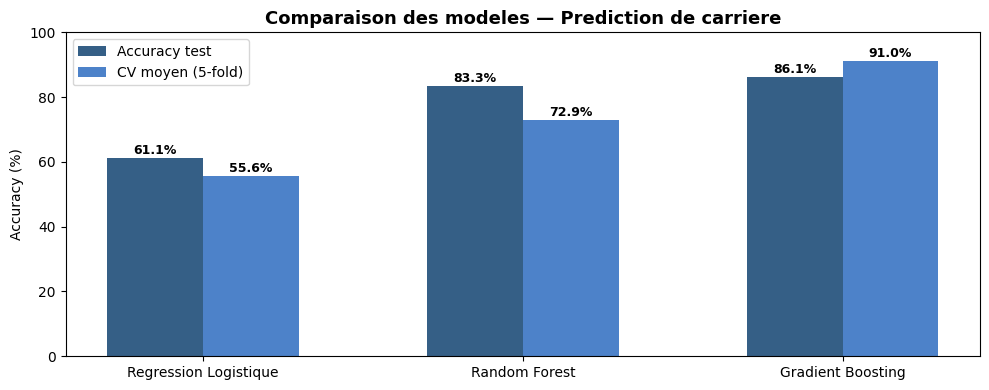

In [8]:
# Visualisation des performances
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_res))
w = 0.3
b1 = ax.bar(x - w/2, df_res['Accuracy test'], w, label='Accuracy test', color='#1F4E79', alpha=0.9)
b2 = ax.bar(x + w/2, df_res['CV moyen'], w, label='CV moyen (5-fold)', color='#3A75C4', alpha=0.9)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Modele'], fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparaison des modeles — Prediction de carriere', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Meilleur modele
meilleur_nom = df_res.loc[df_res['Accuracy test'].idxmax(), 'Modele']
meilleur = modeles[meilleur_nom]
print(f'Meilleur modele : {meilleur_nom}')
y_pred_best = meilleur.predict(X_test_sc)
print(classification_report(y_test, y_pred_best))

Meilleur modele : Gradient Boosting
                        precision    recall  f1-score   support

      Autre Ingenierie       0.64      1.00      0.78         7
         Cybersecurite       0.80      1.00      0.89         4
 Data / Cloud / DevOps       1.00      1.00      1.00         7
      Dev Mobile / Jeu       1.00      0.60      0.75         5
     Developpement Web       1.00      1.00      1.00         4
IA / ML / Data Science       1.00      0.67      0.80         9

              accuracy                           0.86        36
             macro avg       0.91      0.88      0.87        36
          weighted avg       0.91      0.86      0.86        36



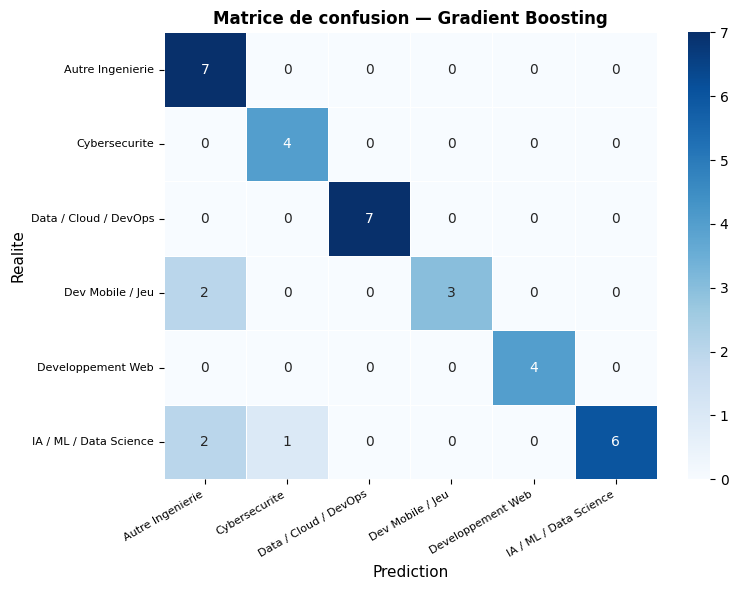

In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best, labels=meilleur.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=meilleur.classes_, yticklabels=meilleur.classes_, linewidths=0.5, ax=ax)
ax.set_xlabel('Prediction', fontsize=11)
ax.set_ylabel('Realite', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
ax.set_title(f'Matrice de confusion — {meilleur_nom}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

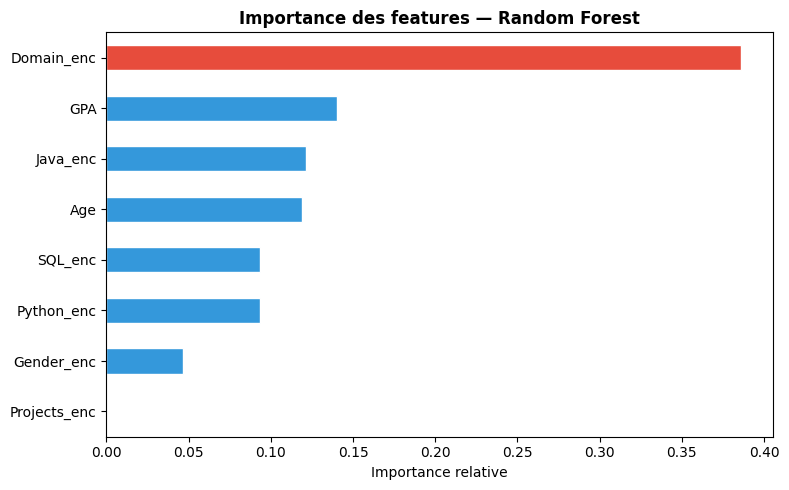

Feature la plus importante : Domain_enc


In [11]:
# Importance des features
rf = modeles['Random Forest']
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#e74c3c' if i == importances.idxmax() else '#3498db' for i in importances.index]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Importance des features — Random Forest', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature la plus importante : {importances.idxmax()}')

In [12]:
# Prediction sur un profil personnalise
def predire_carriere(age, gpa, genre, domaine, python, sql, java, projets):
    skill_map3 = {'Weak': 0, 'Average': 1, 'Strong': 2}
    genre_enc = 1 if genre == 'Male' else 0
    try:
        domain_enc = le_domain.transform([domaine])[0]
    except:
        domain_enc = 0
    X_new = pd.DataFrame([{
        'Age': age, 'GPA': gpa, 'Gender_enc': genre_enc, 'Domain_enc': domain_enc,
        'Python_enc': skill_map3[python], 'SQL_enc': skill_map3[sql],
        'Java_enc': skill_map3[java], 'Projects_enc': projets
    }])
    X_sc = scaler.transform(X_new)
    pred = meilleur.predict(X_sc)[0]
    print(f'Profil : {age} ans, GPA {gpa}, {genre}, interesse par {domaine}')
    print(f'Python: {python} | SQL: {sql} | Java: {java} | Projets: {projets}')
    print(f'Carriere predite : {pred}\n')

predire_carriere(22, 3.8, 'Female', 'Artificial Intelligence', 'Strong', 'Average', 'Weak', 3)
predire_carriere(21, 3.5, 'Male', 'Cybersecurity', 'Average', 'Strong', 'Weak', 1)
predire_carriere(23, 3.7, 'Female', 'Data Science', 'Strong', 'Strong', 'Average', 2)

Profil : 22 ans, GPA 3.8, Female, interesse par Artificial Intelligence
Python: Strong | SQL: Average | Java: Weak | Projets: 3
Carriere predite : IA / ML / Data Science

Profil : 21 ans, GPA 3.5, Male, interesse par Cybersecurity
Python: Average | SQL: Strong | Java: Weak | Projets: 1
Carriere predite : Cybersecurite

Profil : 23 ans, GPA 3.7, Female, interesse par Data Science
Python: Strong | SQL: Strong | Java: Average | Projets: 2
Carriere predite : IA / ML / Data Science



## Conclusion

Ce projet est different de mes deux precedents (NLP) : les donnees sont **tabulaires et structurees**, ce qui m'a permis de travailler sur l'encodage de variables categorielles et l'importance des features.

**Observations :**
- Le domaine d'interet est la feature la plus predictive — logique
- Le GPA joue un role dans certains groupes (IA/ML tend a avoir un GPA plus eleve)
- Le niveau en Python est plus discriminant que SQL ou Java pour les orientations data/IA

**Limite principale :** 180 etudiants, c'est un petit dataset. Les resultats sont indicatifs.

**Pistes d'amelioration :**
- Tester sur un dataset plus grand
- Explorer des approches de clustering pour identifier des profils sans supervision
- Ajouter des features comme les notes par matiere